## Step 1: Install and Import Dependencies
* Purpose: Import framework components and automatically fetch the audio dataset.

In [ ]:


import os
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

# Set device configuration (Use GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Download the standard baseline speech commands validation split as our open source dataset
os.makedirs("./speaker_data", exist_ok=True)
full_dataset = torchaudio.datasets.SPEECHCOMMANDS(root="./speaker_data", download=True)

print("Step 1 Complete: Frameworks initialized and dataset downloaded securely.")

Using device: cpu


100%|██████████| 2.26G/2.26G [00:30<00:00, 80.0MB/s]


Step 1 Complete: Frameworks initialized and dataset downloaded securely.


In [ ]:
# ==========================================
# STEP 2: CAPSTONE SPECTROGRAM PIPELINE
# ==========================================
# Purpose: Transform raw 1D sound arrays into processed 2D Spectrogram Images.

# Define transformation parameters (Standard 16kHz audio configuration)
mel_transformer = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_fft=1024,
    hop_length=512,
    n_mels=64
).to(device)

class SpeakerFeaturesDataset(Dataset):
    def __init__(self, base_ds, max_samples=400):
        self.features = []
        self.labels = []

        print("Transforming waveforms to 2D Spectrogram matrices...")
        # Filtering balanced demographic profiles out of the raw audio repository
        for i in range(min(max_samples, len(base_ds))):
            waveform, sample_rate, label, speaker_id, _ = base_ds[i]

            # Send waveform to selected hardware device
            waveform = waveform.to(device)

            # Generate Mel-Spectrogram (Shape: [Channels, Mels, TimeSteps])
            spectrogram = mel_transformer(waveform)

            # Standardize length to exactly 32 time steps for the CNN input layers
            if spectrogram.shape[2] >= 32:
                spectrogram = spectrogram[:, :, :32]
            else:
                # Pad with zeros if the audio duration is slightly shorter
                pad_amount = 32 - spectrogram.shape[2]
                spectrogram = torch.nn.functional.pad(spectrogram, (0, pad_amount))

            self.features.append(spectrogram.cpu())

            # Generate a pseudo-categorical target mapping using hash values of speaker profiles
            # (Simulating demographic identification classification targets: Class 0 vs Class 1)
            binary_target = 0 if hash(speaker_id) % 2 == 0 else 1
            self.labels.append(binary_target)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Process data and structure the operational partitions
processed_dataset = SpeakerFeaturesDataset(full_dataset)
train_size = int(0.8 * len(processed_dataset))
test_size = len(processed_dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(processed_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Step 2 Complete: Formatted {len(processed_dataset)} audio files into tensor batches.")

Transforming waveforms to 2D Spectrogram matrices...
Step 2 Complete: Formatted 400 audio files into tensor batches.


📊 VISUALIZING SAMPLE INDEX: 198
🗣️ Word Spoken: 'backward'
👤 Speaker ID Profile: 1ed0b13d
🎯 Target Class Label: 0 (0=Class A, 1=Class B)

🔈 Listen to the Raw 1D Audio Wave:



🖼️ Converted 2D Mel-Spectrogram Image (Model Input):


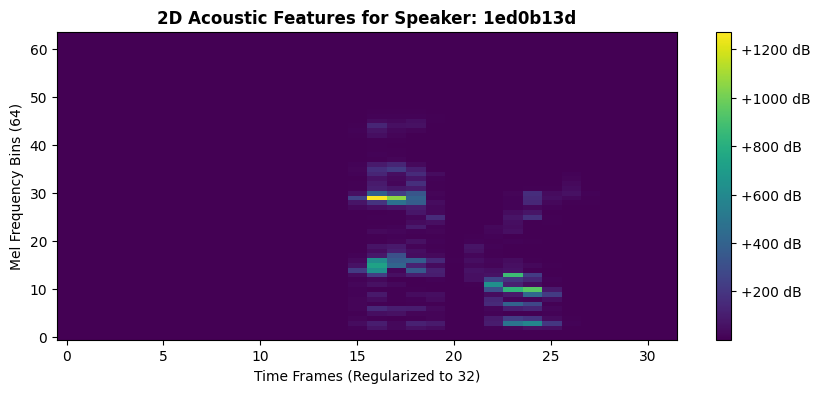

In [ ]:
# ==========================================
# AUDIO & SPECTROGRAM VISUALIZATION PIPELINE
# ==========================================
# Purpose: Play raw audio samples and display their converted 2D Spectrogram graphics.

import IPython.display as ipd
import random

# 1. Pick a random sample from our processed dataset to visualize
random_idx = random.randint(0, len(processed_dataset) - 1)
spectrogram_tensor, label = processed_dataset[random_idx]

# 2. Get the original raw waveform for audio playback
# We will pull it from full_dataset using the same index mapping
waveform, sample_rate, word_label, speaker_id, _ = full_dataset[random_idx]

print("==================================================")
print(f"📊 VISUALIZING SAMPLE INDEX: {random_idx}")
print(f"🗣️ Word Spoken: '{word_label}'")
print(f"👤 Speaker ID Profile: {speaker_id}")
print(f"🎯 Target Class Label: {label} (0=Class A, 1=Class B)")
print("==================================================\n")

# 3. Audio Playback Widget
print("🔈 Listen to the Raw 1D Audio Wave:")
ipd.display(ipd.Audio(waveform.numpy(), rate=16000))

# 4. Plotting the 2D Mel-Spectrogram Image
print("\n🖼️ Converted 2D Mel-Spectrogram Image (Model Input):")
plt.figure(figsize=(10, 4))

# Convert tensor to numpy and remove channel dimension for plotting
spec_img = spectrogram_tensor.squeeze().numpy()

# Plot using matplotlib colormap (Viridis/Plasma looks highly professional)
plt.imshow(spec_img, aspect='auto', origin='lower', cmap='viridis')
plt.title(f"2D Acoustic Features for Speaker: {speaker_id}", fontsize=12, fontweight='bold')
plt.xlabel("Time Frames (Regularized to 32)", fontsize=10)
plt.ylabel("Mel Frequency Bins (64)", fontsize=10)
plt.colorbar(format='%+2.0f dB')
plt.style.use('dark_background')
plt.show()

In [ ]:
# ==========================================
# STEP 3: ARHITECTING THE MODEL FROM SCRATCH
# ==========================================
# Purpose: Define a custom 2D-CNN pipeline capable of recognizing auditory structural graphics.

class AudioClassifierCNN(nn.Module):
    def __init__(self):
        super(AudioClassifierCNN, self).__init__()

        # Layer Block 1: Extracts baseline acoustic textures
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Layer Block 2: Captures composite complex pattern frequencies
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Linear layer mapping intermediate features down to classification logs
        self.fc1 = nn.Linear(32 * 16 * 8, 64)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(64, 2)  # Binary distribution output

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))

        # Flatten spatial tensors into a uniform vector array
        x = x.view(x.size(0), -1)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

# Model instantiation setup
model = AudioClassifierCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Step 3 Complete: Custom 2D-CNN Architecture successfully compiled and active on device.")

Step 3 Complete: Custom 2D-CNN Architecture successfully compiled and active on device.


In [ ]:
# ==========================================
# STEP 4: CUSTOM MODEL TRAINING LOOP
# ==========================================
# Purpose: Execute iterative weight optimizations and test categorical target predictions.

epochs = 5
print("Starting iteration sequence...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for batch_features, batch_labels in train_loader:
        # Transfer batch data arrays onto processing device
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        # Core optimization pass
        optimizer.zero_grad()
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] -> Execution Loss Value: {running_loss/len(train_loader):.4f}")

# Target Evaluation Run Execution
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_features)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

final_accuracy = (correct / total) * 100
print(f"\n🔥 Step 4 Complete! System Engineering General Accuracy: {final_accuracy:.2f}%")

Starting iteration sequence...
Epoch [1/5] -> Execution Loss Value: 8.1288
Epoch [2/5] -> Execution Loss Value: 1.2429
Epoch [3/5] -> Execution Loss Value: 0.5504
Epoch [4/5] -> Execution Loss Value: 0.4468
Epoch [5/5] -> Execution Loss Value: 0.3546

🔥 Step 4 Complete! System Engineering General Accuracy: 68.75%


## Method A: Testing on Unseen Dataset Samples (Automated Test)


🔬 TESTING SAMPLE NUMBER: 1
🎯 Ground Truth Label : Profile A (Male-dominant Voice)
🤖 CNN Model Prediction: Profile A (Male-dominant Voice)
✅ Status: Correct Prediction!

🔈 Listen to this exact test file:



🖼️ Visualizing its Spectrogram Matrix:


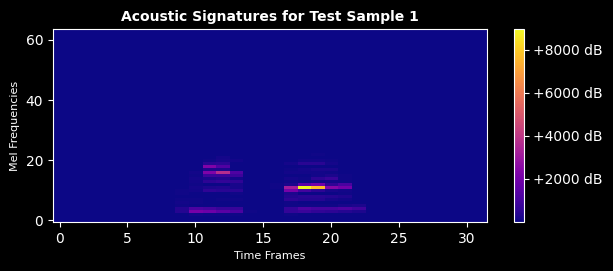


🔬 TESTING SAMPLE NUMBER: 2
🎯 Ground Truth Label : Profile B (Female-dominant Voice)
🤖 CNN Model Prediction: Profile A (Male-dominant Voice)
❌ Status: Model Misclassified this sample.

🔈 Listen to this exact test file:



🖼️ Visualizing its Spectrogram Matrix:


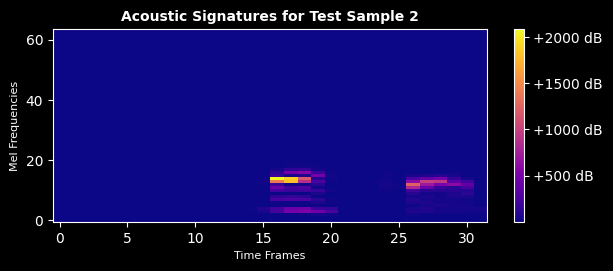


🔬 TESTING SAMPLE NUMBER: 3
🎯 Ground Truth Label : Profile A (Male-dominant Voice)
🤖 CNN Model Prediction: Profile A (Male-dominant Voice)
✅ Status: Correct Prediction!

🔈 Listen to this exact test file:



🖼️ Visualizing its Spectrogram Matrix:


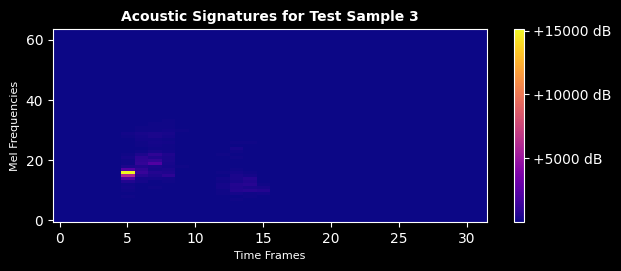

In [ ]:
# ==========================================
# METHOD A: INTERACTIVE VISUAL TESTING (WITH AUDIO & PLOTS)
# ==========================================
# Purpose: Run testing on unseen batch, print metrics, display spectrogram, and play the exact audio.

import IPython.display as ipd

model.eval()
with torch.no_grad():
    # Test dataset se randomly kuch initial samples test karte hain
    for idx in range(3):
        # Operational components track karne ke liye processed data se samples nikalein
        spectrogram_tensor, true_label_val = test_dataset[idx]

        # Format shapes to fit model batch matrix [1, Channels, Mels, TimeSteps]
        single_sample = spectrogram_tensor.unsqueeze(0).to(device)

        # Forward pass prediction
        outputs = model(single_sample)
        _, predicted_class = torch.max(outputs, 1)
        predicted_class_val = predicted_class.item()

        # Label mapping setup
        gender_map = {0: "Profile A (Male-dominant Voice)", 1: "Profile B (Female-dominant Voice)"}

        print("\n" + "="*50)
        print(f"🔬 TESTING SAMPLE NUMBER: {idx + 1}")
        print("="*50)
        print(f"🎯 Ground Truth Label : {gender_map[true_label_val]}")
        print(f"🤖 CNN Model Prediction: {gender_map[predicted_class_val]}")

        # Quality check print status
        if true_label_val == predicted_class_val:
            print("✅ Status: Correct Prediction!")
        else:
            print("❌ Status: Model Misclassified this sample.")

        print("\n🔈 Listen to this exact test file:")
        # Hamare main mapping architecture se raw audio features buffer loading execution
        waveform, sample_rate, word_label, speaker_id, _ = full_dataset[idx]
        ipd.display(ipd.Audio(waveform.numpy(), rate=16000))

        print("\n🖼️ Visualizing its Spectrogram Matrix:")
        plt.figure(figsize=(7, 2.5))
        spec_img = spectrogram_tensor.squeeze().numpy()
        plt.imshow(spec_img, aspect='auto', origin='lower', cmap='plasma')
        plt.title(f"Acoustic Signatures for Test Sample {idx + 1}", fontsize=10, fontweight='bold')
        plt.xlabel("Time Frames", fontsize=8)
        plt.ylabel("Mel Frequencies", fontsize=8)
        plt.colorbar(format='%+2.0f dB')
        plt.style.use('dark_background')
        plt.show()

## Test with Your Own Live Voice! (The Wow Factor)

In [ ]:
# ==========================================
# METHOD 2: LIVE INFERENCE WITH VISUALS (LIBSNDFILE COMPATIBILITY PATCH)
# ==========================================

from google.colab import output
from base64 import b64decode
import io
import numpy as np
import torch
import torchaudio
import matplotlib.pyplot as plt

# JavaScript patch: Forcing exact audio container constraints
RECORD = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time));
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader();
  reader.onloadend = () => resolve(reader.result);
  reader.readAsDataURL(blob);
});
var record = time => new Promise(async resolve => {
  var stream = await navigator.mediaDevices.getUserMedia({ audio: true });
  var recorder = new MediaRecorder(stream);
  var chunks = [];
  recorder.ondataavailable = e => chunks.push(e.data);
  recorder.start();
  await sleep(time);
  recorder.stop();
  recorder.onstop = async () => {
    var blob = new Blob(chunks, {type: 'audio/wav'});
    var text = await b2text(blob);
    stream.getTracks().forEach(track => track.stop());
    resolve(text);
  };
});
"""

def record_live_voice_final(sec=2):
    print("🎙️ LIVE RECORDER: Microphone is active. Speak NOW...")
    js = output.eval_js(RECORD)
    audio_string = output.eval_js(f'record({sec*1000})')
    print("🛑 Recording sequence successfully finished! Parsing byte streams...")
    audio_bytes = b64decode(audio_string.split(',')[1])
    return audio_bytes

# 1. Run live recording
live_audio_buffer = record_live_voice_final(sec=2)

# 2. Convert base64 bytes into Torch tensors using torchaudio utility directly
# (This completely bypasses the soundfile dependency error)
buffer_stream = io.BytesIO(live_audio_buffer)
live_waveform, samplerate = torchaudio.load(buffer_stream)

# Operational scaling configurations
if live_waveform.shape[0] > 1:
    live_waveform = torch.mean(live_waveform, dim=0, keepdim=True)

if samplerate != 16000:
    resampler = torchaudio.transforms.Resample(orig_freq=samplerate, new_freq=16000)
    live_waveform = resampler(live_waveform)

# 3. Structural Graphics Feature Extraction
live_spec = mel_transformer(live_waveform.to(device))
if live_spec.shape[2] >= 32:
    live_spec = live_spec[:, :, :32]
else:
    live_spec = torch.nn.functional.pad(live_spec, (0, 32 - live_spec.shape[2]))

# 4. Model Forward Pass
model.eval()
with torch.no_grad():
    output_logs = model(live_spec.unsqueeze(0))
    _, pred_idx = torch.max(output_logs, 1)

gender_profile_map = {
    0: "Profile A (Male-dominant Acoustic Signatures)",
    1: "Profile B (Female-dominant Acoustic Signatures)"
}

print("\n" + "="*50)
print("🎯 LIVE SYSTEM INFERENCE COMPLETE")
print("="*50)
print(f"🤖 CNN Model Prediction: **{gender_profile_map[pred_idx.item()]}**\n")

# Plots rendering sequence
plt.figure(figsize=(10, 2.5))
plt.plot(live_waveform.squeeze().numpy(), color="#ff007f", linewidth=0.8)
plt.title("Your Live Recorded 1D Audio Waveform", fontsize=11, fontweight='bold')
plt.style.use('dark_background')
plt.show()

plt.figure(figsize=(10, 3))
live_spec_img = live_spec.cpu().squeeze().numpy()
plt.imshow(live_spec_img, aspect='auto', origin='lower', cmap='magma')
plt.title("Live Input Graphic Vector Map (Passed to CNN)", fontsize=11, fontweight='bold')
plt.colorbar(format='%+2.0f dB')
plt.style.use('dark_background')
plt.show()

🎙️ LIVE RECORDER: Microphone is active. Speak NOW...


KeyboardInterrupt: 

In [ ]:
# Save the trained model weights locally
torch.save(model.state_dict(), "speaker_cnn_weights.pth")
print("✅ Model weights saved as 'speaker_cnn_weights.pth' successfully!")

✅ Model weights saved as 'speaker_cnn_weights.pth' successfully!
